In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ieee-fraud-detection/sample_submission.csv
/kaggle/input/ieee-fraud-detection/test_identity.csv
/kaggle/input/ieee-fraud-detection/train_identity.csv
/kaggle/input/ieee-fraud-detection/test_transaction.csv
/kaggle/input/ieee-fraud-detection/train_transaction.csv


# Load the data

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time
import gc
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)

# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Define file paths (adjust as needed)
TRAIN_IDENTITY = '../input/ieee-fraud-detection/train_identity.csv'
TRAIN_TRANSACTION = '../input/ieee-fraud-detection/train_transaction.csv'
TEST_IDENTITY = '../input/ieee-fraud-detection/test_identity.csv'
TEST_TRANSACTION = '../input/ieee-fraud-detection/test_transaction.csv'

# Load the data
print("Loading training transaction data...")
train_transaction = pd.read_csv(TRAIN_TRANSACTION)
print("Loading training identity data...")
train_identity = pd.read_csv(TRAIN_IDENTITY)
print("Loading test transaction data...")
test_transaction = pd.read_csv(TEST_TRANSACTION)
print("Loading test identity data...")
test_identity = pd.read_csv(TEST_IDENTITY)

2025-04-29 18:02:17.981810: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745949738.237525      32 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745949738.305284      32 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Loading training transaction data...
Loading training identity data...
Loading test transaction data...
Loading test identity data...


In [5]:
# Display basic information about the datasets
test_identity.columns = test_identity.columns.str.replace("-", "_")
print("\nTransaction train data shape:", train_transaction.shape)
print("Identity train data shape:", train_identity.shape)
print("Transaction test data shape:", test_transaction.shape)
print("Identity test data shape:", test_identity.shape)
 
 
# Merge train data (transaction and identity)
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
print("\nTrain data shape after merge:", train.shape)

# Merge test data (transaction and identity)
test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')
print("Test data shape after merge:", test.shape)

# Check target variable distribution
print("\nTarget variable distribution:")
print(train['isFraud'].value_counts(normalize=True))

# Sort data by timestamp
train = train.sort_values('TransactionDT')
test = test.sort_values('TransactionDT')

# Free up memory
del train_transaction, train_identity, test_transaction, test_identity
gc.collect()



Transaction train data shape: (590540, 394)
Identity train data shape: (144233, 41)
Transaction test data shape: (506691, 393)
Identity test data shape: (141907, 41)

Train data shape after merge: (590540, 434)
Test data shape after merge: (506691, 433)

Target variable distribution:
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


16

# Exploratory Data Analysis

In [ ]:
 
# Check data types
print("Data types:")
print(train.dtypes.value_counts())

# Check for missing values
print("\nMissing values in train set:")
missing_train = (train.isnull().sum() / len(train)) * 100
print(missing_train[missing_train > 0].sort_values(ascending=False).head(20))

# Examine some key features
print("\nSample of categorical features (P_emaildomain):")
print(train['P_emaildomain'].value_counts().head(10))

print("\nTransaction amount statistics:")
print(train['TransactionAmt'].describe())

# Plot transaction amount distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(train['TransactionAmt'].clip(0, 2000), bins=100)
plt.title('Transaction Amount Distribution (clipped at 2000)')
plt.xlabel('Amount')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(train['TransactionAmt']), bins=100)
plt.title('Log Transaction Amount Distribution')
plt.xlabel('Log(Amount + 1)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Examine fraud distribution over time
plt.figure(figsize=(12, 6))
temp = train.copy()
temp['DT_D'] = temp['TransactionDT'] / (24 * 60 * 60)  # Convert to days
daily_fraud = temp.groupby(temp['DT_D'].astype(int))['isFraud'].mean()
plt.plot(daily_fraud.index, daily_fraud.values)
plt.title('Daily Fraud Rate')
plt.xlabel('Day')
plt.ylabel('Fraud Rate')
plt.grid(True)
plt.show()

# Relationship between card info and fraud
plt.figure(figsize=(15, 10))
for i, feature in enumerate(['card1', 'card2', 'card3', 'card4', 'card5', 'card6']):
    if feature in train.columns:
        plt.subplot(2, 3, i+1)
        fraud_rate = train.groupby(feature)['isFraud'].mean()
        fraud_rate.sort_values(ascending=False).head(20).plot(kind='bar')
        plt.title(f'Fraud Rate by {feature}')
        plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()
 

# Feature Selection

In [6]:
# 1. Drop features with high percentage of null values
def drop_high_null_columns(df, threshold=0.9):
    """Drop columns with more than the threshold of missing values"""
    null_percentage = df.isnull().mean()
    high_null_cols = null_percentage[null_percentage > threshold].index.tolist()
    print(f"Dropping {len(high_null_cols)} columns with more than {threshold*100}% missing values")
    return df.drop(columns=high_null_cols), high_null_cols

train, high_null_cols = drop_high_null_columns(train, threshold=0.9)
test = test.drop(columns=[col for col in high_null_cols if col in test.columns])

print(f"Train shape after dropping high-null columns: {train.shape}")
print(f"Test shape after dropping high-null columns: {test.shape}")

Dropping 12 columns with more than 90.0% missing values
Train shape after dropping high-null columns: (590540, 422)
Test shape after dropping high-null columns: (506691, 421)


In [15]:
# 2. Identify and drop highly correlated features
def drop_correlated_features(df, target_col='isFraud', threshold=0.9):
    """
    For each pair of highly correlated columns, drop the one with more unique values
    as specified in the readme
    """
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)
    
    if len(numeric_cols) < 2:
        return df, []
    
    corr_matrix = df[numeric_cols].corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find pairs of features with correlation above threshold
    correlated_pairs = [(upper_tri.index[i], upper_tri.columns[j], upper_tri.iloc[i, j]) 
                       for i in range(len(upper_tri.index)) 
                       for j in range(len(upper_tri.columns)) 
                       if upper_tri.iloc[i, j] > threshold]
    
    # Sort by correlation value
    correlated_pairs.sort(key=lambda x: x[2], reverse=True)
    
    to_drop = set()
    for col1, col2, corr_val in correlated_pairs:
        if col1 not in to_drop and col2 not in to_drop:
            # Get number of unique values for each feature
            nunique1 = df[col1].nunique()
            nunique2 = df[col2].nunique()
            
            # Remove the feature with more unique values (as per the readme)
            if nunique1 > nunique2:
                to_drop.add(col1)
            else:
                to_drop.add(col2)
    
    print(f"Dropping {len(to_drop)} columns due to high correlation")
    return df.drop(columns=list(to_drop)), list(to_drop)

# Only perform correlation check on numeric features
numeric_train = train.select_dtypes(include=['number'])
train, correlated_cols = drop_correlated_features(numeric_train, threshold=0.95)
test = test.drop(columns=[col for col in correlated_cols if col in test.columns])

print(f"Train shape after dropping correlated columns: {train.shape}")
print(f"Test shape after dropping correlated columns: {test.shape}")
 

KeyboardInterrupt: 

In [7]:
## 3. Adversarial Validation
 
def adversarial_validation(train_df, test_df, n_estimators=100):
    """
    Perform adversarial validation to ensure time consistency between train and test sets.
    Returns a list of features that are not consistent over time.
    """
    print("Performing adversarial validation...")
    
    # Create a dataset for adversarial validation
    train_sample = train_df.sample(min(len(train_df), 50000), random_state=SEED)
    test_sample = test_df.sample(min(len(test_df), 50000), random_state=SEED)
    
    # Add a target column (1 for test, 0 for train)
    train_sample['is_test'] = 0
    test_sample['is_test'] = 1
    
    # Combine the datasets
    combined = pd.concat([train_sample, test_sample])
    
    # Get only the features present in both datasets
    features = [col for col in train_df.columns if col in test_df.columns 
               and col != 'TransactionID' and col != 'TransactionDT']
    
    # Drop non-numeric features for this check
    numeric_features = combined[features].select_dtypes(include=['number']).columns.tolist()
    
    # Fill missing values for the model
    X = combined[numeric_features].fillna(-999)
    y = combined['is_test']
    
    # Train a model to distinguish between train and test
    model = xgb.XGBClassifier(n_estimators=n_estimators, random_state=SEED)
    model.fit(X, y)
    
    # Get feature importance
    importance = model.feature_importances_
    
    # Get features with high importance (these are inconsistent between train and test)
    inconsistent_features = []
    importance_df = pd.DataFrame({
        'feature': numeric_features,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    # Select features with importance above threshold (top 10%)
    threshold = np.percentile(importance, 90)
    inconsistent_features = importance_df[importance_df['importance'] > threshold]['feature'].tolist()
    
    print(f"Found {len(inconsistent_features)} inconsistent features")
    return inconsistent_features

# Prepare data for adversarial validation
train_for_adv = train.copy()
test_for_adv = test.copy()

# Run adversarial validation
inconsistent_features = adversarial_validation(train_for_adv, test_for_adv)

# Remove inconsistent features
train = train.drop(columns=[col for col in inconsistent_features if col in train.columns])
test = test.drop(columns=[col for col in inconsistent_features if col in test.columns])

print(f"Train shape after removing inconsistent features: {train.shape}")
print(f"Test shape after removing inconsistent features: {test.shape}")
 

Performing adversarial validation...
Found 39 inconsistent features
Train shape after removing inconsistent features: (590540, 383)
Test shape after removing inconsistent features: (506691, 382)


# Feature Engineering

In [8]:
 
# First, let's identify different types of features
def categorize_features(df):
    binary_features = []
    low_card_features = []
    high_card_features = []
    
    # Iterate through all non-numeric columns
    for col in df.select_dtypes(exclude=['number']).columns:
        nunique = df[col].nunique()
        if nunique == 2:
            binary_features.append(col)
        elif nunique <= 10:
            low_card_features.append(col)
        else:
            high_card_features.append(col)
    
    return binary_features, low_card_features, high_card_features

binary_features, low_card_features, high_card_features = categorize_features(train)

print(f"Binary features: {len(binary_features)}")
print(f"Low cardinality features: {len(low_card_features)}")
print(f"High cardinality features: {len(high_card_features)}")

Binary features: 17
Low cardinality features: 6
High cardinality features: 6


## Binary encoding

In [9]:
# 1. Binary encoding
def binary_encode(df, features):
    """Convert binary categorical features into 0/1"""
    df_copy = df.copy()
    for col in features:
        if col in df_copy.columns:
            # Get the two unique values
            unique_vals = df_copy[col].dropna().unique()
            if len(unique_vals) == 2:
                # Map the values to 0/1
                df_copy[col + '_binary'] = df_copy[col].map({unique_vals[0]: 0, unique_vals[1]: 1})
                # Drop the original column
                df_copy = df_copy.drop(columns=[col])
    return df_copy

train = binary_encode(train, binary_features)
test = binary_encode(test, binary_features)

## One-hot encoding

In [10]:
# 2. One-hot encoding for low cardinality features
def one_hot_encode(train_df, test_df, features):
    """One-hot encode categorical features with low cardinality"""
    train_copy = train_df.copy()
    test_copy = test_df.copy()
    
    for col in features:
        if col in train_copy.columns and col in test_copy.columns:
            # Get unique values from train
            unique_vals = train_copy[col].dropna().unique()
            if len(unique_vals) == 3:
            # Create one-hot encoded columns
                for val in unique_vals:
                    col_name = f"{col}_{val}"
                    train_copy[col_name] = (train_copy[col] == val).astype(int)
                    test_copy[col_name] = (test_copy[col] == val).astype(int)
                
                # Drop the original column
                train_copy = train_copy.drop(columns=[col])
                test_copy = test_copy.drop(columns=[col])
    
    return train_copy, test_copy

train, test = one_hot_encode(train, test, low_card_features)

## Frequency encoding

In [20]:
# 3. Frequency encoding for high cardinality features
def time_based_frequency_encode(train_df, test_df, features):
    """
    Frequency encode high cardinality features with time-awareness
    For each value, encode it as n_e/n where:
    - n_e: number of rows before the sample where the value e occurs
    - n: total number of rows before the current timestamp
    """
    encoded_train = train_df.copy()
    encoded_test = test_df.copy()
    
    for col in features:
        if col in train_df.columns and col in test_df.columns:
            # Create new column names
            freq_col = f"{col}_freq"
            
            # Initialize with 0
            encoded_train[freq_col] = 0.0
            encoded_test[freq_col] = 0.0
            
            # Dictionary to store counts
            val_counts = {}
            total_rows = 0
            
            # Process training data
            for i, (idx, row) in enumerate(encoded_train.iterrows()):
                val = row[col]
                
                # Calculate frequency
                if pd.notna(val):
                    val_count = val_counts.get(val, 0)
                    encoded_train.at[idx, freq_col] = val_count / max(1, total_rows)
                    
                    # Update counts
                    val_counts[val] = val_counts.get(val, 0) + 1
                
                total_rows += 1
                
                # Print progress
                if i % 50000 == 0:
                    print(f"Processing {col}, row {i}/{len(encoded_train)}")
            
            # Process test data using frequencies from train
            for i, (idx, row) in enumerate(encoded_test.iterrows()):
                val = row[col]
                
                # Calculate frequency based on train data
                if pd.notna(val):
                    val_count = val_counts.get(val, 0)
                    encoded_test.at[idx, freq_col] = val_count / max(1, total_rows)
                
                if i % 50000 == 0:
                    print(f"Processing test {col}, row {i}/{len(encoded_test)}")
            
            # Drop original column
            encoded_train = encoded_train.drop(columns=[col])
            encoded_test = encoded_test.drop(columns=[col])
    
    return encoded_train, encoded_test

# Apply frequency encoding to a subset of high-cardinality features for efficiency
# In a production scenario, you'd want to process all of them
high_card_sample = high_card_features[:3] if len(high_card_features) >= 3 else high_card_features  # Just using first 3 for this example
train, test = time_based_frequency_encode(train, test, high_card_sample)

Processing P_emaildomain, row 0/590540
Processing P_emaildomain, row 50000/590540


KeyboardInterrupt: 

## Time-based expanding window features

In [11]:
# 4. Create time-based expanding window features
def create_time_window_features(train_df, test_df, id_cols, target='isFraud'):
    """
    Create time-based aggregation features using ID columns
    For example, ratio of frauds committed from a particular email domain
    before the given timestamp
    """
    result_train = train_df.copy()
    result_test = test_df.copy()
    
    for col in id_cols:
        if col in train_df.columns and col in test_df.columns:
            # Skip if the column has too many missing values
            if train_df[col].isna().mean() > 0.5:
                continue
                
            print(f"Creating time-based features for {col}")
            
            # Create a dictionary to store aggregations
            count_dict = {}
            fraud_dict = {}
            
            # Feature names
            count_col = f"{col}_count_before"
            fraud_col = f"{col}_fraud_count_before"
            fraud_rate_col = f"{col}_fraud_rate_before"
            
            # Initialize columns
            result_train[count_col] = 0
            result_train[fraud_col] = 0
            result_train[fraud_rate_col] = 0
            
            result_test[count_col] = 0
            result_test[fraud_col] = 0
            result_test[fraud_rate_col] = 0
            
            # Process training data
            for i, (idx, row) in enumerate(result_train.iterrows()):
                val = row[col]
                
                if pd.notna(val):
                    # Get current counts
                    count = count_dict.get(val, 0)
                    fraud_count = fraud_dict.get(val, 0)
                    
                    # Update features
                    result_train.at[idx, count_col] = count
                    result_train.at[idx, fraud_col] = fraud_count
                    result_train.at[idx, fraud_rate_col] = fraud_count / max(1, count)
                    
                    # Update dictionaries
                    count_dict[val] = count + 1
                    fraud_dict[val] = fraud_count + (1 if row[target] == 1 else 0)
                
                if i % 50000 == 0:
                    print(f"  Processing row {i}/{len(result_train)}")
            
            # Process test data using aggregations from train
            for i, (idx, row) in enumerate(result_test.iterrows()):
                val = row[col]
                
                if pd.notna(val):
                    # Get counts from training
                    count = count_dict.get(val, 0)
                    fraud_count = fraud_dict.get(val, 0)
                    
                    # Update features
                    result_test.at[idx, count_col] = count
                    result_test.at[idx, fraud_col] = fraud_count
                    result_test.at[idx, fraud_rate_col] = fraud_count / max(1, count)
                
                if i % 50000 == 0:
                    print(f"  Processing test row {i}/{len(result_test)}")
    
    return result_train, result_test

# Select a few ID columns to create time-window features
id_cols = ['P_emaildomain', 'R_emaildomain', 'card1', 'card2', 'addr1', 'addr2']
id_cols = [col for col in id_cols if col in train.columns and col in test.columns]

# Create time-window features with a sample of data for demonstration
# train_sample = train.head(10000)
# test_sample = test.head(5000)
# train_with_time_features, test_with_time_features = create_time_window_features(
#     train_sample, test_sample, id_cols
# )

# In a real scenario, you would run this on the full dataset
train, test = create_time_window_features(train, test, id_cols)

# train = train_with_time_features
# test = test_with_time_features

print(f"Final train shape: {train.shape}")
print(f"Final test shape: {test.shape}")
 

Creating time-based features for P_emaildomain
  Processing row 0/590540
  Processing row 50000/590540
  Processing row 100000/590540
  Processing row 150000/590540
  Processing row 200000/590540
  Processing row 250000/590540
  Processing row 300000/590540
  Processing row 350000/590540
  Processing row 400000/590540
  Processing row 450000/590540
  Processing row 500000/590540
  Processing row 550000/590540
  Processing test row 0/506691
  Processing test row 50000/506691
  Processing test row 100000/506691
  Processing test row 150000/506691
  Processing test row 200000/506691
  Processing test row 250000/506691
  Processing test row 300000/506691
  Processing test row 350000/506691
  Processing test row 400000/506691
  Processing test row 450000/506691
  Processing test row 500000/506691
Creating time-based features for card1
  Processing row 0/590540
  Processing row 50000/590540
  Processing row 100000/590540
  Processing row 150000/590540
  Processing row 200000/590540
  Process

# Model Training and Evaluation

In [12]:
# Get features for modeling (drop ID columns and target)
features = [col for col in train.columns if col not in ['TransactionID', 'TransactionDT', 'isFraud']]

# Handle missing values - fill with -999
X_train = train[features].fillna(-999)
y_train = train['isFraud']
X_test = test[features].fillna(-999)  # This is the missing X_test definition

# Use time-based validation (as described in the readme)
# The validation set will be the last 20% of the training data
split_idx = int(len(X_train) * 0.8)
X_train_split = X_train.iloc[:split_idx]
y_train_split = y_train.iloc[:split_idx]
X_val = X_train.iloc[split_idx:]
y_val = y_train.iloc[split_idx:]

print(f"Training data shape: {X_train_split.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"Test data shape: {X_test.shape}")  # Added this line to show test data shape
 

Training data shape: (472432, 399)
Validation data shape: (118108, 399)
Test data shape: (506691, 399)


## XGBoost Model

In [ ]:
### XGBoost Model

 
def train_xgb_model(X_train, y_train, X_val, y_val):
    obj_cols = X_train.select_dtypes(include='object').columns
    X_train[obj_cols] = X_train[obj_cols].astype('category')

    """Train and evaluate XGBoost model"""
    print("Training XGBoost model...")
    
    # Set parameters
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'learning_rate': 0.05,
        'max_depth': 5,
        'min_child_weight': 30,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'eta': 0.05,
        'seed': SEED
    }
    
    # Create DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
    dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)
    
    # Train model
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=5000,  # Will use early stopping
        evals=[(dtrain, 'train'), (dval, 'val')],
        early_stopping_rounds=100,
        verbose_eval=100
    )
    
    # Make predictions
    y_pred = model.predict(dval)
    
    # Calculate AUC
    auc = roc_auc_score(y_val, y_pred)
    print(f"XGBoost Validation AUC: {auc:.4f}")
    
    # Feature importance
    importance = model.get_score(importance_type='gain')
    importance_df = pd.DataFrame(
        {'feature': list(importance.keys()), 'importance': list(importance.values())}
    ).sort_values('importance', ascending=False)
    
    print("\nTop 10 important features:")
    print(importance_df.head(10))
    
    return model, auc, importance_df

# Train XGBoost model
xgb_model, xgb_auc, xgb_importance = train_xgb_model(X_train_split, y_train_split, X_val, y_val)

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=xgb_importance.head(20))
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

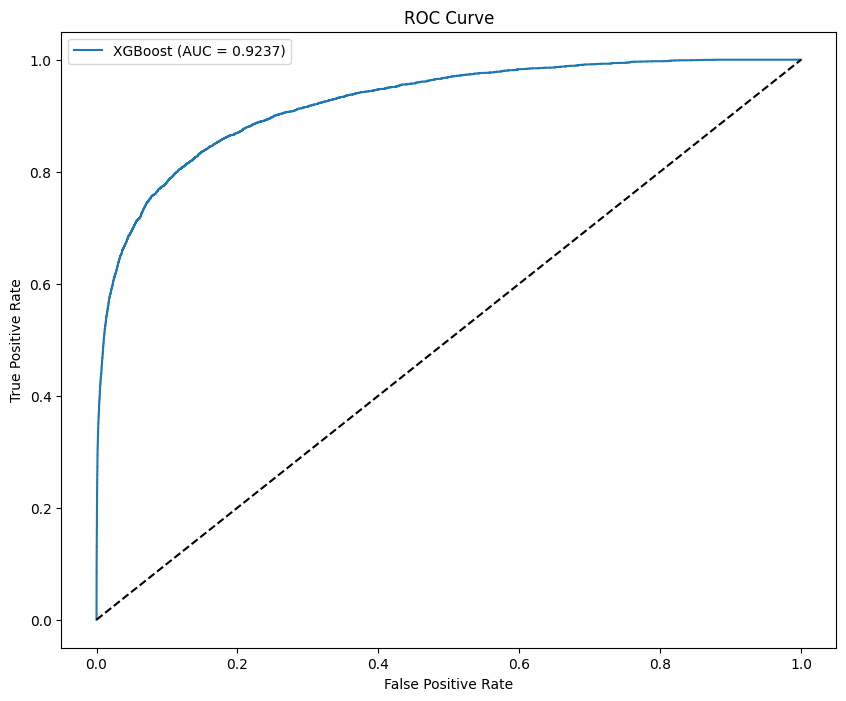

In [17]:
# Plot ROC curve
obj_cols = X_val.select_dtypes(include='object').columns
X_val[obj_cols] = X_val[obj_cols].astype('category')
y_pred_xgb = xgb_model.predict(xgb.DMatrix(X_val, enable_categorical=True))
fpr, tpr, _ = roc_curve(y_val, y_pred_xgb)
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {xgb_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [18]:
!pip install mlflow dagshub --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 55.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 91.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.1/260.1 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 692.3/692.3 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.2/203.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This be

In [19]:
import mlflow
from dagshub import dagshub_logger
import os

# Set tracking URI manually
mlflow.set_tracking_uri("https://dagshub.com/ekvirika/FraudDerection.mlflow")

# Use your DagsHub credentials
os.environ["MLFLOW_TRACKING_USERNAME"] = "ekvirika"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "3f601f2c2c7a6bca448ebc69f4f5d4b49daffd8f"

# Optional: set registry if you're using model registry
mlflow.set_registry_uri("https://dagshub.com/ekvirika/FraudDerection.mlflow")



In [20]:
def train_xgb_model(X_train, y_train, X_val, y_val, experiment_name="XGBoost_Training"):
    """Train XGBoost model and log everything to MLflow"""
    print("Training XGBoost model...")
    obj_cols = X_train.select_dtypes(include='object').columns
    X_train[obj_cols] = X_train[obj_cols].astype('category')
    X_val[obj_cols] = X_val[obj_cols].astype('category')

    # Set experiment
    mlflow.set_experiment(experiment_name)

    with mlflow.start_run():
        params = {
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'learning_rate': 0.05,
            'max_depth': 5,
            'min_child_weight': 30,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'eta': 0.05,
            'seed': SEED,
        }

        mlflow.log_params(params)

        dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
        dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=5000,
            evals=[(dtrain, 'train'), (dval, 'val')],
            early_stopping_rounds=100,
            verbose_eval=100
        )

        y_pred = model.predict(dval)
        auc = roc_auc_score(y_val, y_pred)
        mlflow.log_metric("val_auc", auc)
        print(f"XGBoost Validation AUC: {auc:.4f}")

        # Feature importance
        importance = model.get_score(importance_type='gain')
        importance_df = pd.DataFrame({
            'feature': list(importance.keys()),
            'importance': list(importance.values())
        }).sort_values('importance', ascending=False)

        # Log feature importance plot
        plt.figure(figsize=(12, 8))
        sns.barplot(x='importance', y='feature', data=importance_df.head(20))
        plt.title('XGBoost Feature Importance')
        plt.tight_layout()
        imp_path = "xgb_feature_importance.png"
        plt.savefig(imp_path)
        mlflow.log_artifact(imp_path)
        plt.close()

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_val, y_pred)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc:.4f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()
        roc_path = "xgb_roc_curve.png"
        plt.savefig(roc_path)
        mlflow.log_artifact(roc_path)
        plt.close()

        # Save model
        mlflow.xgboost.log_model(model, artifact_path="xgboost_model")

        # Optional: log feature importance as CSV
        importance_df.to_csv("feature_importance.csv", index=False)
        mlflow.log_artifact("feature_importance.csv")

        return model, auc, importance_df


In [ ]:
xgb_model, xgb_auc, xgb_importance = train_xgb_model(X_train_split, y_train_split, X_val, y_val, experiment_name="XGBoost_Training")


Training XGBoost model...
[0]	train-auc:0.82688	val-auc:0.81935
[100]	train-auc:0.92464	val-auc:0.90363
[200]	train-auc:0.93657	val-auc:0.91254
